In [1]:
!pip install sentence-transformers matplotlib seaborn scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
sentences = [
    # Cricket
    "The batsman hit a century in the match.",
    "The bowler took an important wicket.",
    "The captain changed the fielding position.",
    "The team won the cricket tournament.",

    # Cooking
    "She added salt to the soup.",
    "The chef baked a cake in the oven.",
    "They cooked rice and vegetables for dinner.",

    # Cybersecurity
    "Strong passwords help protect accounts.",
    "The company used a firewall for security.",
    "Phishing emails can steal user information."
]

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [5]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df

,The batsman hit a century in the match.,The bowler took an important wicket.,The captain changed the fielding position.,The team won the cricket tournament.,She added salt to the soup.,The chef baked a cake in the oven.,They cooked rice and vegetables for dinner.,Strong passwords help protect accounts.,The company used a firewall for security.,Phishing emails can steal user information.
The batsman hit a century in the match.,1.000000,0.627923,0.472192,0.541713,-0.041702,0.109455,0.090003,-0.020476,0.012369,-0.046640
The bowler took an important wicket.,0.627923,1.000000,0.469705,0.534666,0.110060,0.157341,0.109339,0.037355,0.044136,-0.041934
The captain changed the fielding position.,0.472192,0.469705,1.000000,0.368939,0.012138,0.047972,0.074880,0.014894,0.079843,-0.011585
The team won the cricket tournament.,0.541713,0.534666,0.368939,1.000000,0.019966,0.123897,0.188187,-0.002150,0.112516,-0.019462
She added salt to the soup.,-0.041702,0.110060,0.012138,0.019966,1.000000,0.100819,0.312893,0.014913,0.076874,0.002167
The chef baked a cake in the oven.,0.109455,0.157341,0.047972,0.123897,0.100819,1.000000,0.230917,-0.095091,0.060703,0.119163
They cooked rice and vegetables for dinner.,0.090003,0.109339,0.074880,0.188187,0.312893,0.230917,1.000000,-0.039159,0.056449,-0.019464
Strong passwords help protect accounts.,-0.020476,0.037355,0.014894,-0.002150,0.014913,-0.095091,-0.039159,1.000000,0.252270,0.450193
The company used a firewall for security.,0.012369,0.044136,0.079843,0.112516,0.076874,0.060703,0.056449,0.252270,1.000000,0.235155
Phishing emails can steal user information.,-0.046640,-0.041934,-0.011585,-0.019462,0.002167,0.119163,-0.019464,0.450193,0.235155,1.000000


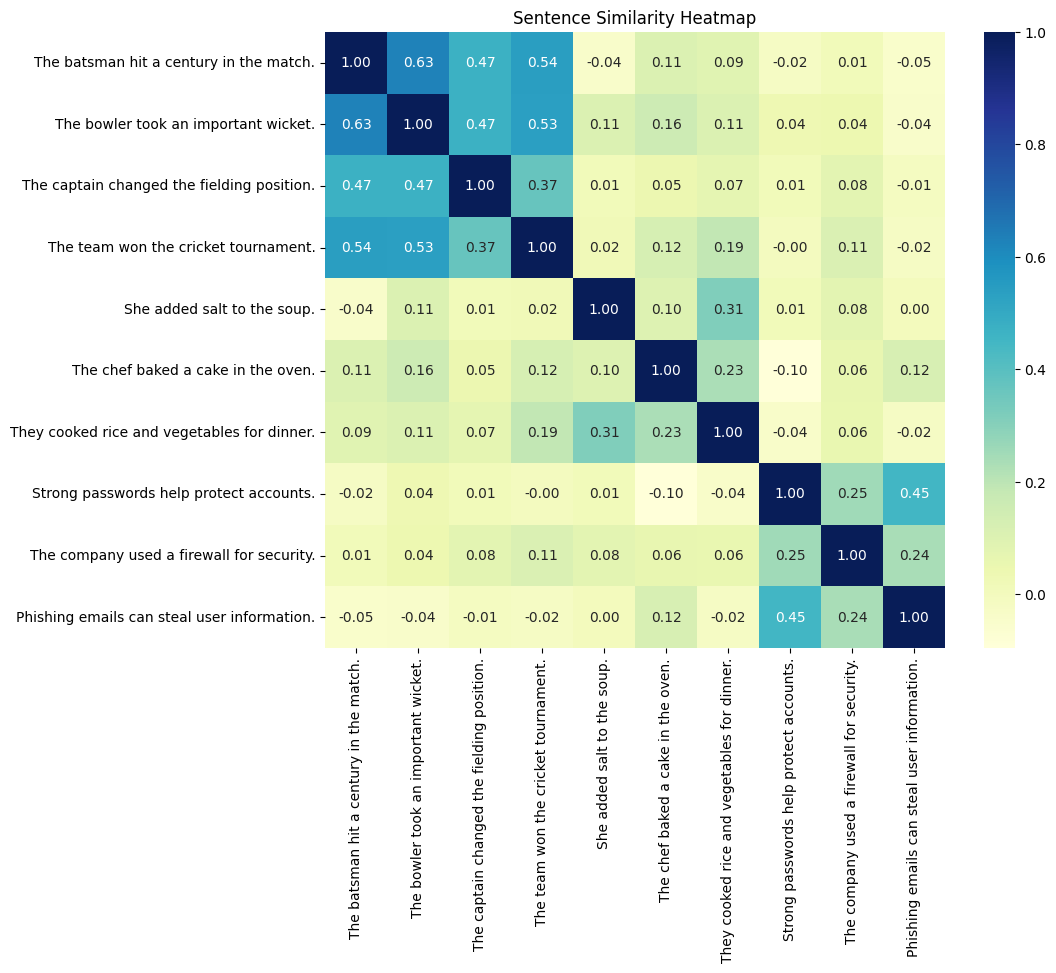

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
scores = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, scores))
results = sorted(results, key=lambda x: x[1], reverse=True)

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for sentence, score in results[:2]:
    print(sentence, "-", round(score, 4))

Query: The bowler took three wickets in one over

Top 2 similar sentences:

The bowler took an important wicket. - 0.8043
The batsman hit a century in the match. - 0.5692
